
🚀 Melatih Agen dengan strategi: BALANCED

🚀 Melatih Agen dengan strategi: AGGRESSIVE


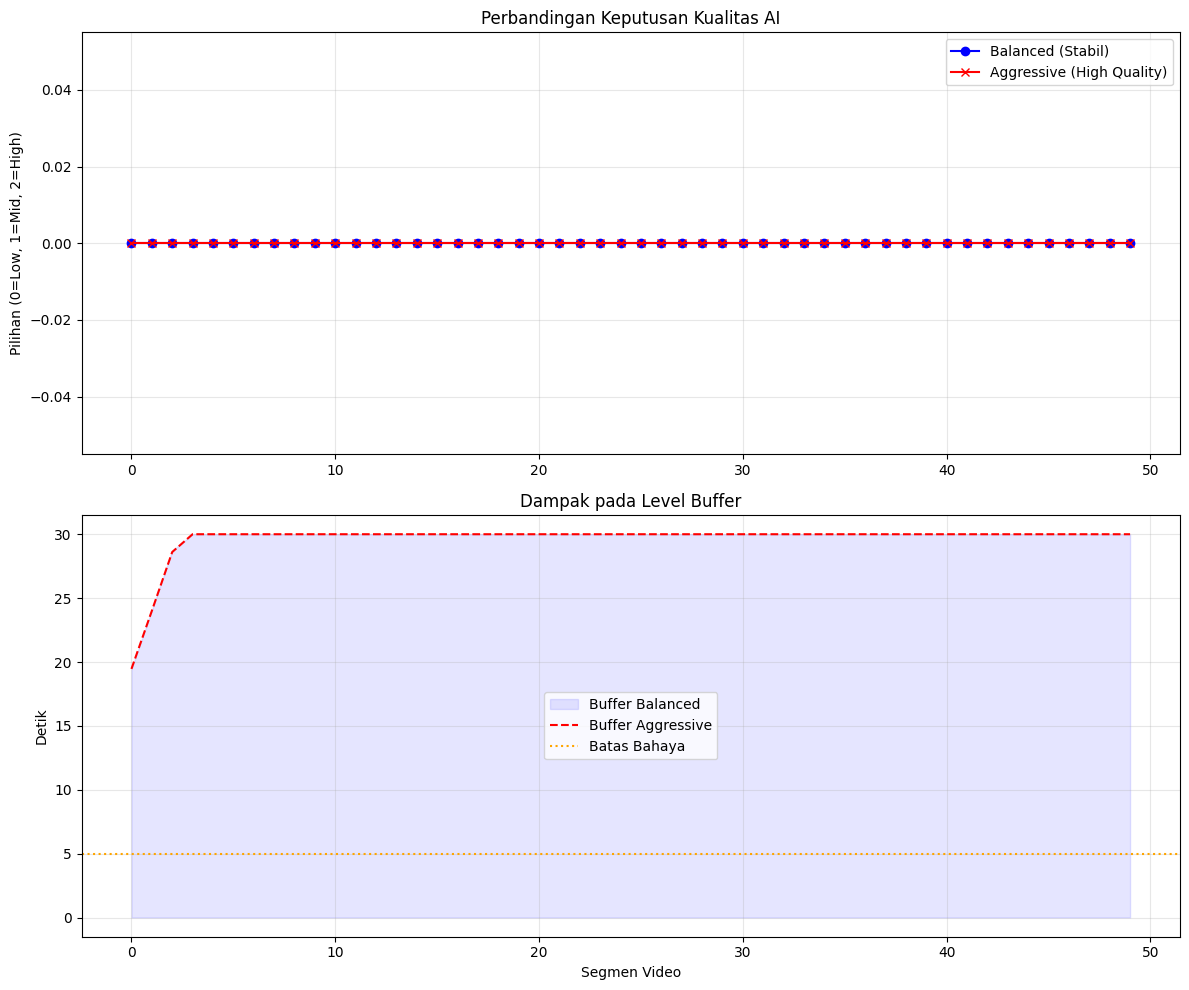


✅ Analisis Selesai. Perhatikan bagaimana strategi 'Aggressive' lebih sering memilih High Quality namun dengan risiko Buffer yang lebih rendah.


In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
import os

class ShakaNDNEnv(gym.Env):
    """
    Simulator Lingkungan Shaka Player pada NDN.
    Mendukung berbagai tipe reward untuk eksperimen.
    """
    def __init__(self, reward_type="balanced"):
        super(ShakaNDNEnv, self).__init__()
        self.reward_type = reward_type
        
        # Action: 0=Low (0.5Mbps), 1=Mid (2.5Mbps), 2=High (8.0Mbps)
        self.action_space = spaces.Discrete(3)
        self.bitrate_levels = [0.5, 2.5, 8.0]

        # Observation: [Buffer, Throughput, LastQual, RTT, Dropped]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0]),
            high=np.array([30, 20, 2, 1000, 100]),
            dtype=np.float32
        )

        self.state = None
        self.max_steps = 100
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Mulai dengan kondisi moderat
        self.state = np.array([15.0, 5.0, 1.0, 50.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, throughput, last_qual, rtt, dropped = self.state
        chosen_bitrate = self.bitrate_levels[action]

        # Simulasi Jaringan
        segment_duration = 5.0 # detik
        segment_size = chosen_bitrate * segment_duration
        
        # Waktu download dipengaruhi throughput dan latensi NDN
        download_time = (segment_size / (throughput + 0.1)) + (rtt / 1000.0)

        # Update Buffer
        # Selama download, buffer berkurang. Setelah selesai, bertambah durasi segmen.
        stalling = 0
        new_buffer = buffer - download_time
        if new_buffer < 0:
            stalling = abs(new_buffer)
            new_buffer = 0
        new_buffer += segment_duration
        new_buffer = min(new_buffer, 30.0)

        # --- EKSPERIMEN METODE REWARD ---
        reward = 0
        
        if self.reward_type == "aggressive":
            # Fokus pada kualitas setinggi mungkin
            reward = chosen_bitrate * 2.0
            reward -= (stalling * 100) # Penalti macet tetap ada tapi fokus pada kualitas
            
        elif self.reward_type == "safe":
            # Sangat takut macet, kualitas nomor sekian
            reward = chosen_bitrate * 0.5
            reward -= (stalling * 200)
            if new_buffer < 10: reward -= 20 # Penalti jika buffer di bawah 10 detik

        elif self.reward_type == "balanced":
            # Keseimbangan (Bitrate - Stalling - Instability)
            reward = chosen_bitrate 
            reward -= (stalling * 60)
            # Penalti ganti kualitas (agar tidak kedap-kedip)
            reward -= abs(action - last_qual) * 2.0
            # Bonus jika buffer sehat
            if new_buffer > 15: reward += 1.0

        # Update Jaringan untuk langkah berikutnya (Random Walk)
        new_throughput = np.clip(throughput + np.random.uniform(-2, 2), 0.5, 20.0)
        new_rtt = np.clip(rtt + np.random.uniform(-30, 30), 10, 500)
        
        self.state = np.array([new_buffer, new_throughput, float(action), new_rtt, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {}

def train_and_evaluate(r_type):
    print(f"\n🚀 Melatih Agen dengan strategi: {r_type.upper()}")
    env = ShakaNDNEnv(reward_type=r_type)
    model = PPO("MlpPolicy", env, verbose=0, learning_rate=0.0005)
    model.learn(total_timesteps=30000)
    
    # Evaluasi
    obs, _ = env.reset()
    history = []
    for i in range(50):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        history.append({
            'Step': i,
            'Buffer': obs[0],
            'Throughput': obs[1],
            'Quality': action,
            'Reward': reward
        })
    return pd.DataFrame(history)

# Jalankan eksperimen untuk dua tipe berbeda
df_balanced = train_and_evaluate("balanced")
df_aggressive = train_and_evaluate("aggressive")

# --- Visualisasi Perbandingan ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot Kualitas (Pilihan AI)
ax1.plot(df_balanced['Step'], df_balanced['Quality'], label='Balanced (Stabil)', color='blue', marker='o')
ax1.plot(df_aggressive['Step'], df_aggressive['Quality'], label='Aggressive (High Quality)', color='red', marker='x')
ax1.set_title("Perbandingan Keputusan Kualitas AI")
ax1.set_ylabel("Pilihan (0=Low, 1=Mid, 2=High)")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot Buffer
ax2.fill_between(df_balanced['Step'], df_balanced['Buffer'], color='blue', alpha=0.1, label='Buffer Balanced')
ax2.plot(df_aggressive['Step'], df_aggressive['Buffer'], color='red', label='Buffer Aggressive', linestyle='--')
ax2.axhline(y=5, color='orange', linestyle=':', label='Batas Bahaya')
ax2.set_title("Dampak pada Level Buffer")
ax2.set_ylabel("Detik")
ax2.set_xlabel("Segmen Video")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Analisis Selesai. Perhatikan bagaimana strategi 'Aggressive' lebih sering memilih High Quality namun dengan risiko Buffer yang lebih rendah.")

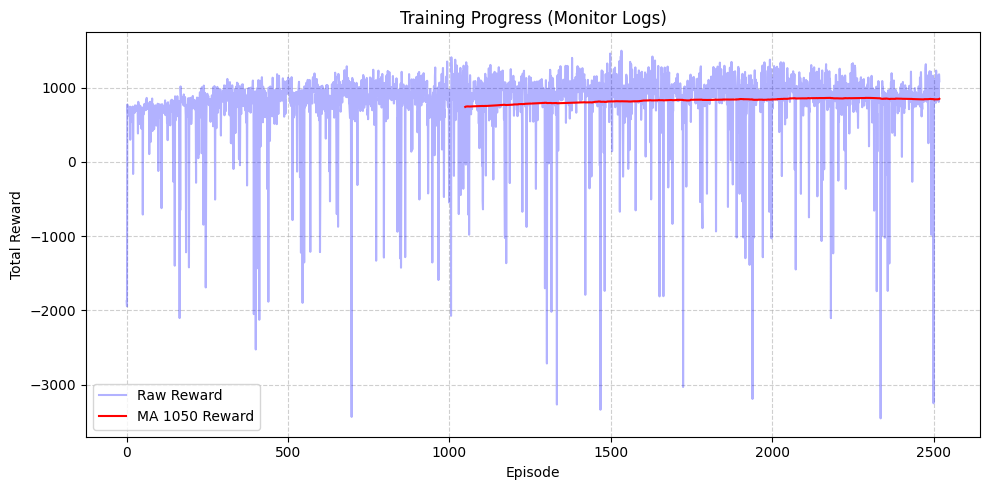

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Sesuaikan dengan path file kamu
log_dir = "./rl_logs_8bitrate/"
file_path = os.path.join(log_dir, "2.monitor.csv")

# 1. Load data
# skiprows=1 digunakan karena baris pertama biasanya header JSON dari SB3
df = pd.read_csv(file_path, skiprows=1)

# 2. Hitung Moving Average (supaya grafik lebih halus/tidak terlalu berantakan)
window_size = 1050
df['rolling_reward'] = df['r'].rolling(window=window_size).mean()

# 3. Buat Plot
plt.figure(figsize=(10, 5))

# Plot reward asli (transparan)
plt.plot(df.index, df['r'], alpha=0.3, color='blue', label='Raw Reward')

# Plot moving average (garis tebal)
plt.plot(df.index, df['rolling_reward'], color='red', label=f'MA {window_size} Reward')

plt.title('Training Progress (Monitor Logs)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

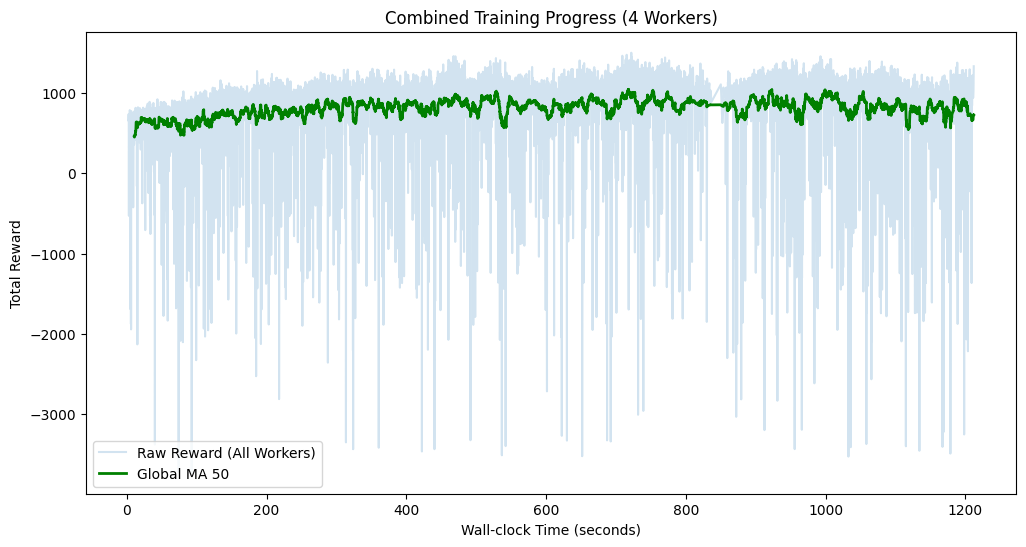

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# 1. Ambil semua file monitor (0.monitor.csv, 1.monitor.csv, dst)
log_dir = "./rl_logs_8bitrate/"
all_files = glob.glob(os.path.join(log_dir, "*.monitor.csv"))

# 2. Baca dan gabungkan
li = []
for filename in all_files:
    # Skiprows=1 karena baris pertama adalah header JSON
    df = pd.read_csv(filename, skiprows=1)
    li.append(df)

# Gabungkan berdasarkan waktu (kolom 't') agar urutannya sinkron
combined_df = pd.concat(li, axis=0, ignore_index=True)
combined_df = combined_df.sort_values('t') 

# 3. Plot hasil gabungan
window = 50
combined_df['rolling'] = combined_df['r'].rolling(window=window).mean()

plt.figure(figsize=(12, 6))
plt.plot(combined_df['t'], combined_df['r'], alpha=0.2, label='Raw Reward (All Workers)')
plt.plot(combined_df['t'], combined_df['rolling'], color='green', linewidth=2, label=f'Global MA {window}')
plt.title('Combined Training Progress (4 Workers)')
plt.xlabel('Wall-clock Time (seconds)')
plt.ylabel('Total Reward')
plt.legend()
plt.show()